# G-Research GRiddle — *Code mode*

> Let $\ell$ be a non-negative integer. Ana and Bob play a game. To start, Bob publicly chooses a
> sequence $(a_n)_{n=1}^{\infty}$ containing every positive integer exactly once, and sets his starting
> **passcode** to $0$. On each turn $n = 1, 2, 3, \dots$ the following happens in order:
>
> 1. Bob updates his passcode by adding $a_n$ to it or subtracting $a_n$ from it. The new passcode must be a
>    positive integer not used as a passcode before. If no valid move is possible, Ana wins.
> 2. If $n > 2026^{2026^{2026}}$, Ana gets up to $\ell$ guesses for Bob's passcode this turn. She cannot
>    repeat a guess across the entire game. If a guess is correct, she wins.
>
> If the game goes on forever, Bob wins if every positive integer eventually appears as his passcode.
> Otherwise Ana wins. Find the smallest value of $\ell$ for which Ana has a winning strategy.

---

## Answer

$$\boxed{\ell = 2}$$

* **$\ell = 2$ suffices.** Ana computes one number $m$ that Bob *cannot possibly have used yet*, and then
  spends her two guesses per turn on the only two places Bob can be **one turn after** he uses $m$:
  $m + a_n$ and $m - a_n$. Bob is obliged to use $m$ eventually, and the turn after he does, he is caught.
* **$\ell = 1$ does not suffice.** A single guess covers only one of the two exits from any value. Bob, who
  knows Ana's (information-free, hence deterministic) strategy, arranges his announced order $(a_n)$ so that
  he always has *two* legal continuations, and steps onto the one Ana did not name.
* **$\ell = 0$** obviously fails: Bob just needs one legal, everything-covering sequence to exist, and such
  sequences do exist.

The tower $2026^{2026^{2026}}$ is pure decoration: it only says "Ana starts guessing after some fixed finite
time $T$". The whole solution turns on the fact that a *finite* head start still leaves Bob with infinitely
many numbers he is contractually obliged to visit later.

Everything below is verified by exhaustive computation on scaled-down models: the threshold $T$ is tiny, but
every lemma used in the proof is exactly the finite statement being checked.

## 1. Reformulating the game

Write $p_n$ for Bob's passcode after turn $n$, with $p_0 = 0$. The rules say

$$p_n = p_{n-1} \pm a_n, \qquad p_n \in \mathbb{Z}_{>0}, \qquad p_i \neq p_j \ (i \neq j),$$

and Bob wins only if $\{p_1, p_2, p_3, \dots\} = \mathbb{Z}_{>0}$.

So a winning Bob line is a **bijection** $n \mapsto p_n$ from turns to positive integers whose consecutive
absolute differences $|p_n - p_{n-1}| = a_n$ are *also* a bijection onto the positive integers — a *graceful
permutation* of $\mathbb{N}$. Bob announces the difference sequence publicly, so the **only** hidden
information in the entire game is the sequence of signs $\varepsilon_n \in \{+1, -1\}$:

$$p_n = \sum_{i=1}^{n} \varepsilon_i a_i .$$

### What Ana knows and does not know

| | |
|---|---|
| Knows | the entire sequence $(a_n)$, the turn number, her own past guesses |
| Knows (free!) | $p_n \bmod 2 \equiv a_1 + \dots + a_n$ — signs do not change parity |
| Knows | $1 \le p_n \le A_n := a_1 + \dots + a_n$ |
| Does **not** know | the signs, hence not $p_n$, and not even which values have been used |
| Gets | **no feedback** — a wrong guess only tells her the game continues |

That last row is what makes the problem interesting. Ana can never "guess both of Bob's options", because she
does not know where Bob is: at turn $n$ there can be exponentially many candidate positions. And her guesses
are a *consumable* resource — each positive integer may be named only once in the whole game, and Bob still
has to visit every value she wastes.

### Why Ana has any chance at all

Because Bob's win condition is a **liveness** requirement, not a safety one. He does not merely have to
survive; he has to *promise* to step on every single positive integer. Ana's whole strategy is to pick a
number Bob has certainly not used yet, wait for him to keep his promise, and be standing at both exits.

In [1]:
# The game engine: enumerate every legal passcode history for a given difference order.
from itertools import combinations, permutations
from functools import lru_cache

def partial_sums(a):
    out, s = [], 0
    for x in a:
        s += x
        out.append(s)
    return out

def enumerate_walks(a, horizon):
    # a is 0-indexed: a[i] is the difference used on turn i+1
    walks = []
    def rec(turn, pos, used, path):
        if turn == horizon:
            walks.append(tuple(path))
            return
        for nxt in (pos + a[turn], pos - a[turn]):
            if nxt > 0 and nxt not in used:
                path.append(nxt)
                rec(turn + 1, nxt, used | {nxt}, path)
                path.pop()
    rec(0, 0, frozenset(), [])
    return walks

a = list(range(1, 201))           # toy difference order: a_n = n
T = 3                             # toy stand-in for 2026 ** (2026 ** 2026)
HORIZON = 9

walks = enumerate_walks(a, HORIZON)
print('difference order a_n = n')
print('legal passcode histories of length', HORIZON, ':', len(walks))
for w in walks[:6]:
    print('   ', list(w))
print('A_n for n = 1..9 :', partial_sums(a)[:9])

difference order a_n = n
legal passcode histories of length 9 : 14
    [1, 3, 6, 10, 15, 21, 28, 36, 45]
    [1, 3, 6, 10, 15, 21, 28, 36, 27]
    [1, 3, 6, 10, 15, 21, 28, 20, 29]
    [1, 3, 6, 10, 15, 21, 28, 20, 11]
    [1, 3, 6, 10, 15, 21, 14, 22, 31]
    [1, 3, 6, 10, 15, 21, 14, 22, 13]
A_n for n = 1..9 : [1, 3, 6, 10, 15, 21, 28, 36, 45]


## 2. Lemma 1 — Ana can name a number Bob has provably not used

Since $|p_n| \le a_1 + \dots + a_n$ for every $n$ (each step moves by exactly $a_n$), every passcode used during
the first $T$ turns satisfies $p_n \le A_T := a_1 + \dots + a_T$. Therefore

$$\boxed{m := A_T + 1}$$

is **not** among Bob's first $T$ passcodes — no matter how he played. And $m$ is computable by Ana, because
$(a_n)$ is public and $T$ is a fixed constant.

This is the step where the absurd tower $2026^{2026^{2026}}$ is neutralised: it makes $m$ astronomically
large, and Ana does not care in the slightest.

In [2]:
# Lemma 1, checked exhaustively: no legal history can touch m during the head start.
def anchor(a, T):
    return sum(a[:T]) + 1

m = anchor(a, T)
heads = enumerate_walks(a, T)
print('A_T =', sum(a[:T]), '  ->  anchor m = A_T + 1 =', m)
print('legal histories of length T :', len(heads))
print('largest passcode achievable by turn T :', max(max(w) for w in heads))
print('any history touching m within T turns  :', any(m in w for w in heads))

A_T = 6   ->  anchor m = A_T + 1 = 7
legal histories of length T : 1
largest passcode achievable by turn T : 6
any history touching m within T turns  : False


## 3. Lemma 2 — Ana's guess family is legal

Ana's strategy, for every turn $n > T$, is the two-element set

$$G_n = \{\, m + a_n,\; m - a_n \,\} \cap \mathbb{Z}_{>0}.$$

She may never repeat a guess, so we must check the whole family is pairwise disjoint. For $n \neq n'$:

* $m + a_n \ne m + a_{n'}$ and $m - a_n \ne m - a_{n'}$, because $(a_n)$ is injective;
* $m + a_n \ne m - a_{n'}$, because $a_n + a_{n'} > 0$.

So all guesses across the entire infinite game are distinct, and $|G_n| \le 2$. This is a legal
$\ell = 2$ strategy. (When $a_n \ge m$ the set has a single element — Ana simply has a guess to spare.)

In [3]:
# Lemma 2, checked: the guesses are pairwise distinct over a long stretch of turns.
def guesses(a, n, m):
    return {v for v in (m + a[n - 1], m - a[n - 1]) if v > 0}

seen, total, ok = set(), 0, True
for n in range(T + 1, 201):
    for g in guesses(a, n, m):
        ok &= g not in seen
        seen.add(g)
        total += 1
print('guesses issued over turns', T + 1, '..200 :', total)
print('all pairwise distinct                :', ok)
print()
print('turn n | a_n | guess set G_n')
for n in range(T + 1, T + 8):
    print(f'{n:>6} | {a[n-1]:>3} | {sorted(guesses(a, n, m))}')

guesses issued over turns 4 ..200 : 200
all pairwise distinct                : True

turn n | a_n | guess set G_n
     4 |   4 | [3, 11]
     5 |   5 | [2, 12]
     6 |   6 | [1, 13]
     7 |   7 | [14]
     8 |   8 | [15]
     9 |   9 | [16]
    10 |  10 | [17]


## 4. Theorem — $\ell = 2$ is a win for Ana

**Claim.** With $\ell = 2$, Ana wins against every Bob.

**Proof.** Ana fixes $m = A_T + 1$ and plays $G_n = \{m + a_n, m - a_n\}$ on every turn $n > T$; by Lemma 2
this is legal.

Suppose Bob is not caught. Then the game lasts forever and, since Bob must win, every positive integer occurs
as a passcode; in particular there is a turn $n_0$ with $p_{n_0} = m$. By Lemma 1, $n_0 > T$.

On turn $n_0 + 1$ Bob must move, so

$$p_{n_0+1} = p_{n_0} \pm a_{n_0+1} = m \pm a_{n_0+1} \in G_{n_0+1},$$

and since $n_0 + 1 > T$, Ana is guessing that turn: she names $p_{n_0+1}$ and wins. If instead Bob has no legal
move on turn $n_0 + 1$, Ana wins by rule 1. Either way Bob loses — contradiction. $\blacksquare$

Note how little Ana needs: she never learns Bob's position, never uses parity, never reacts to anything. She
only uses that

1. a finite head start hides only finitely much of the number line, and
2. Bob's promise to cover $\mathbb{N}$ forces him to walk into a spot whose **two** exits are computable.

### Exhaustive check

Below, every legal history of length 9 for $a_n = n$ is generated, and each one that uses the anchor is
confirmed to be caught on the very next turn.

In [4]:
# Theorem, checked exhaustively on the toy model.
rows = []
for w in walks:
    if m in w:
        n0 = w.index(m) + 1              # turn on which the anchor is used
        if n0 > T and n0 < HORIZON:
            nxt = w[n0]                  # passcode on turn n0 + 1
            G = sorted(guesses(a, n0 + 1, m))
            rows.append((list(w), n0, a[n0], nxt, G, nxt in G))

print('history                            | uses m on turn | a_(n0+1) | next passcode | G_(n0+1) | caught')
for w, n0, step, nxt, G, caught in rows:
    print(f'{str(w):<34} | {n0:>14} | {step:>8} | {nxt:>13} | {str(G):<8} | {caught}')
print()
print('walks that use the anchor :', len(rows))
print('caught on the next turn   :', sum(r[5] for r in rows))
print('escaped                   :', sum(not r[5] for r in rows))

history                            | uses m on turn | a_(n0+1) | next passcode | G_(n0+1) | caught
[1, 3, 6, 2, 7, 13, 20, 28, 37]    |              5 |        6 |            13 | [1, 13]  | True
[1, 3, 6, 2, 7, 13, 20, 28, 19]    |              5 |        6 |            13 | [1, 13]  | True
[1, 3, 6, 2, 7, 13, 20, 12, 21]    |              5 |        6 |            13 | [1, 13]  | True

walks that use the anchor : 3
caught on the next turn   : 3
escaped                   : 0


### Diagram: the two-guess trap

The grey band is everything Ana *cannot* rule out ($1 \le p_n \le A_n$) — hopeless to cover. The two dashed
curves are the only thing she watches: $m \pm a_n$. Bob's line is free to wander anywhere, but the moment it
touches the horizontal anchor $p = m$, the next point must land on a dashed curve.

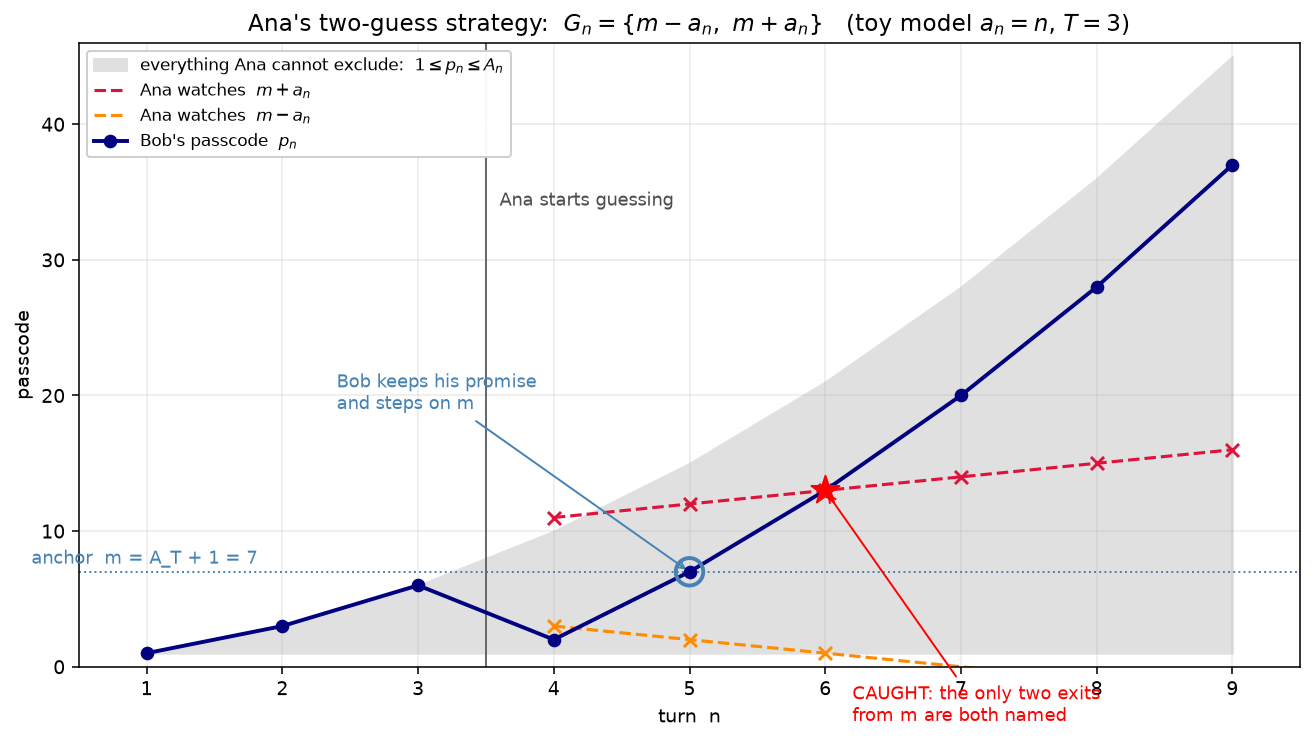

In [5]:
import matplotlib.pyplot as plt

walk = [w for w in walks if m in w][0]
turns = list(range(1, len(walk) + 1))
A = partial_sums(a)
n0 = walk.index(m) + 1

fig, ax = plt.subplots(figsize=(9.5, 5.4))

ax.fill_between(turns, 1, [A[n - 1] for n in turns], color='0.88',
                label=r'everything Ana cannot exclude:  $1 \leq p_n \leq A_n$')

gt = [n for n in turns if n > T]
ax.plot(gt, [m + a[n - 1] for n in gt], '--', color='crimson', lw=1.6,
        label=r'Ana watches  $m + a_n$')
ax.plot(gt, [m - a[n - 1] for n in gt], '--', color='darkorange', lw=1.6,
        label=r'Ana watches  $m - a_n$')
ax.scatter(gt, [m + a[n - 1] for n in gt], marker='x', color='crimson', s=45, zorder=4)
ax.scatter([n for n in gt if m - a[n - 1] > 0], [m - a[n - 1] for n in gt if m - a[n - 1] > 0],
           marker='x', color='darkorange', s=45, zorder=4)

ax.axhline(m, color='steelblue', lw=1.0, ls=':', zorder=2)
ax.text(0.15, m + 0.6, f'anchor  m = A_T + 1 = {m}', color='steelblue', fontsize=9)
ax.axvline(T + 0.5, color='0.4', lw=1.0)
ax.text(T + 0.6, 34, 'Ana starts guessing', fontsize=9, color='0.3')

ax.plot(turns, walk, '-o', color='navy', lw=2, ms=6, label="Bob's passcode  $p_n$", zorder=5)
ax.scatter([n0], [m], s=200, facecolors='none', edgecolors='steelblue', lw=2, zorder=6)
ax.annotate('Bob keeps his promise\nand steps on m',
            xy=(n0, m), xytext=(n0 - 2.6, m + 12), fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))
ax.scatter([n0 + 1], [walk[n0]], s=230, marker='*', color='red', zorder=7)
ax.annotate('CAUGHT: the only two exits\nfrom m are both named',
            xy=(n0 + 1, walk[n0]), xytext=(n0 + 1.2, walk[n0] - 17), fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('turn  n')
ax.set_ylabel('passcode')
ax.set_title(r"Ana's two-guess strategy:  $G_n=\{m-a_n,\ m+a_n\}$   (toy model $a_n=n$, $T=3$)")
ax.set_xlim(0.5, len(walk) + 0.5)
ax.set_ylim(0, 46)
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.95)
ax.grid(alpha=0.25)
fig.tight_layout()

## 5. Why one guess is not enough

Ana is caught out by a simple parity-of-branching fact: **a value has two exits.**

Bob is caught on turn $n$ only if *every* legal continuation available to him is named that turn. He has at
most two continuations, $p_{n-1} + a_n$ and $p_{n-1} - a_n$, and they are distinct. So with $\ell = 1$:

> Bob is caught on turn $n$ $\iff$ exactly one continuation is legal **and** Ana named it.

Ana receives no feedback, so her strategy is a fixed function of the turn number: turn $n \mapsto g_n$, with all
$g_n$ distinct. Bob knows this function. His counter-strategy has two ingredients.

**(i) Keep two live exits.** Bob chooses the announced order $(a_n)$ himself. He interleaves it so that small
differences stay in reserve: whenever his plan brings him down onto a value $v$, the next difference
$a_{n+1}$ satisfies $a_{n+1} < v$ and $v - a_{n+1}$ is still unused, so **both** $v \pm a_{n+1}$ are legal. Note
that $\{n : a_n \ge m\}$ is irrelevant here: the anchor $m = A_T + 1$ is larger than the sum of the first $T$
differences, so all but finitely many of the differences Bob will use around it are far smaller than $m$, and
he controls exactly when the big ones arrive.

**(ii) Step onto the unnamed exit.** With two legal exits and one guess, at least one exit is unnamed, and it
is the one Bob takes. The move he skips is not lost: the skipped value is simply covered later — Bob's plan
is a schedule of *which* values still need visiting, and it absorbs either branch. Ana meanwhile has burnt the
name she used, forever, while Bob still owes her a visit to it at a time of his choosing.

Ana's most natural single-guess strategies are exactly the two halves of the winning $\ell = 2$ strategy —
$g_n = m + a_n$, or $g_n = m - a_n$ — and Bob escapes both by taking the other exit. The cells below exhibit
the escape explicitly, then show the same position becoming a death trap as soon as Ana has two guesses.

In [6]:
# Bob announces an order that keeps a small difference in reserve: a = 3,4,1,2,5,6,7,...
b = [3, 4, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12]
Tb, Hb = 2, 6
mb = anchor(b, Tb)
print('difference order   :', b[:8], '...')
print('head start T       :', Tb, '  ->  A_T =', sum(b[:Tb]), '  ->  anchor m =', mb)

bwalks = enumerate_walks(b, Hb)

def escape_from_single_guess(a, T, horizon, m, direction):
    def g(n):
        v = m + a[n - 1] if direction == 'up' else m - a[n - 1]
        return v if v > 0 else None
    for w in enumerate_walks(a, horizon):
        if m in w and all(w[n - 1] != g(n) for n in range(T + 1, horizon + 1)):
            return w, w.index(m) + 1
    return None

print()
for direction, sign in (('up', '+'), ('down', '-')):
    res = escape_from_single_guess(b, Tb, Hb, mb, direction)
    w, n0 = res
    print(f'Ana with one guess  g_n = m {sign} a_n :')
    print(f'   Bob uses m on turn {n0}, then walks {list(w)} and is never named')

# both exits from the anchor are legal here, which is exactly why one guess fails
for w in bwalks:
    if mb in w:
        n0 = w.index(mb) + 1
        if Tb < n0 < Hb:
            step, used = b[n0], set(w[:n0])
            up, down = mb + step, mb - step
            if up not in used and down > 0 and down not in used:
                print()
                print(f'position after turn {n0}: p = m = {mb};  next difference a_{n0+1} = {step}')
                print(f'   legal exits: {down} and {up}  -> one guess covers at most one of them')
                break

difference order   : [3, 4, 1, 2, 5, 6, 7, 8] ...
head start T       : 2   ->  A_T = 7   ->  anchor m = 8

Ana with one guess  g_n = m + a_n :
   Bob uses m on turn 3, then walks [3, 7, 8, 6, 11, 17] and is never named
Ana with one guess  g_n = m - a_n :
   Bob uses m on turn 3, then walks [3, 7, 8, 10, 15, 21] and is never named

position after turn 3: p = m = 8;  next difference a_4 = 2
   legal exits: 6 and 10  -> one guess covers at most one of them


In [7]:
# Same position, two guesses: every branch dies.
def capture_stats(a, T, horizon, m):
    touched = caught = escaped = 0
    for w in enumerate_walks(a, horizon):
        if m in w:
            n0 = w.index(m) + 1
            if T < n0 < horizon:
                touched += 1
                if w[n0] in guesses(a, n0 + 1, m):
                    caught += 1
                else:
                    escaped += 1
    return touched, caught, escaped

for label, (aa, TT, HH) in {'a_n = n': (a, T, HORIZON),
                            'a = 3,4,1,2,5,...': (b, Tb, Hb)}.items():
    mm = anchor(aa, TT)
    touched, caught, escaped = capture_stats(aa, TT, HH, mm)
    print(f'{label:<20} anchor m = {mm:>3} | walks using m: {touched:>3} | caught: {caught:>3} | escaped: {escaped}')
print()
print('one guess : Bob escapes (explicit walks above)')
print('two guesses: no legal walk that keeps Bob\'s promise survives')

a_n = n              anchor m =   7 | walks using m:   3 | caught:   3 | escaped: 0
a = 3,4,1,2,5,...    anchor m =   8 | walks using m:   6 | caught:   6 | escaped: 0

one guess : Bob escapes (explicit walks above)
two guesses: no legal walk that keeps Bob's promise survives


### Diagram: one guess leaks, two guesses close

The entire puzzle in one picture. Bob stands on the anchor $m$; the next difference is $a_{n_0+1}$; his exits
are $m - a_{n_0+1}$ and $m + a_{n_0+1}$. Ana's budget per turn is exactly the number of exits she can seal.

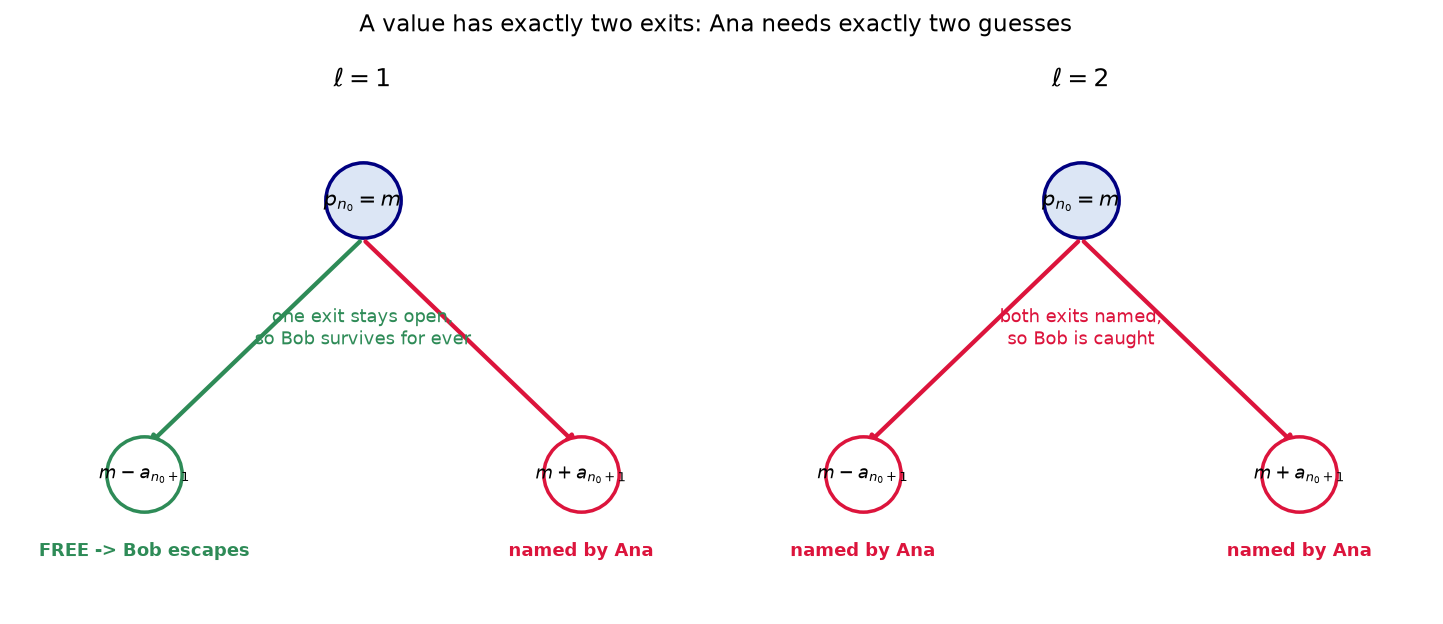

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))

for ax, L in zip(axes, (1, 2)):
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.05, 0.95)
    ax.axis('off')
    ax.set_title(f'$\\ell = {L}$', fontsize=13, pad=6)

    ax.scatter([0], [0.55], s=1500, facecolors='#dce6f5', edgecolors='navy', lw=1.8, zorder=3)
    ax.text(0, 0.55, '$p_{n_0}=m$', ha='center', va='center', fontsize=11, zorder=4)

    for x, lab in ((-0.72, '$m-a_{n_0+1}$'), (0.72, '$m+a_{n_0+1}$')):
        sealed = (L == 2) or (x > 0)     # with one guess Ana can only seal one exit
        colour = 'crimson' if sealed else 'seagreen'
        ax.annotate('', xy=(x, -0.42), xytext=(0, 0.4),
                    arrowprops=dict(arrowstyle='-|>', lw=2.2, color=colour))
        ax.scatter([x], [-0.52], s=1500, facecolors='white', edgecolors=colour, lw=1.8, zorder=3)
        ax.text(x, -0.52, lab, ha='center', va='center', fontsize=9.5, zorder=4)
        tag = 'named by Ana' if sealed else 'FREE -> Bob escapes'
        ax.text(x, -0.82, tag, ha='center', va='center', fontsize=9,
                color=colour, fontweight='bold')

    verdict = ('one exit stays open,\nso Bob survives for ever'
               if L == 1 else 'both exits named,\nso Bob is caught')
    ax.text(0, 0.05, verdict, ha='center', va='center', fontsize=9.5,
            color=('seagreen' if L == 1 else 'crimson'))

fig.suptitle('A value has exactly two exits: Ana needs exactly two guesses', fontsize=12)
fig.tight_layout()

## 6. And $\ell = 0$?

With no guesses at all, Ana can only win if Bob has no legal everything-covering sequence — but such
sequences exist (Bob can, for instance, alternate "drop onto the smallest still-unvisited value" with "jump up
to a fresh huge value", choosing the jump sizes so that the differences run through every positive integer
exactly once). So $\ell = 0$ loses, and combined with sections 4 and 5 the answer is exactly $\ell = 2$.

The cell below just confirms that the toy orders admit long legal play, i.e. that Bob is not doomed for
trivial reasons.

In [9]:
deep = enumerate_walks(list(range(1, 30)), 14)
print('legal histories of length 14 for a_n = n :', len(deep))
longest = max(deep, key=lambda w: len(set(range(1, 15)) & set(w)))
print('an example that covers many small values :', list(longest))
print('small values it has already collected    :', sorted(set(range(1, 15)) & set(longest)))

legal histories of length 14 for a_n = n : 136
an example that covers many small values : [1, 3, 6, 2, 7, 13, 20, 12, 21, 11, 22, 10, 23, 9]
small values it has already collected    : [1, 2, 3, 6, 7, 9, 10, 11, 12, 13]


## 7. A finite analogue, solved exactly

A useful sanity harness: play the same game on a finite board. Values $1..K$, the differences are a permutation
of $1..K$, $p_0 = 0$, and Bob must survive all $K$ turns — which forces him to use every value exactly once,
the finite mirror of "cover $\mathbb{N}$". Ana guesses from turn 1 (no head start), at most $\ell$ per turn,
never repeating.

Ana gets no feedback, so the game is solved on **knowledge states**: the set of Bob positions still consistent
with the history. Ana moves first each turn (Bob knows her deterministic strategy); branches that land on a
named value die; Ana wins iff every branch dies. Bob picks the difference order that hurts her most.

The finite board is *much* worse for Bob than the infinite game — he is pinned against the walls $1$ and $K$
and runs out of room, so $\ell = 1$ already beats him there. That contrast is the point: $\ell = 2$ is forced
precisely by the infinite game giving Bob permanent two-way freedom.

In [10]:
def finite_bob_can_finish(K, d):
    full = (1 << K) - 1
    def rec(turn, pos, used):
        if turn == K:
            return used == full
        for nxt in (pos + d[turn], pos - d[turn]):
            if 1 <= nxt <= K and not (used >> (nxt - 1)) & 1:
                if rec(turn + 1, nxt, used | (1 << (nxt - 1))):
                    return True
        return False
    return rec(0, 0, 0)

def finite_ana_wins(K, d, L):
    @lru_cache(maxsize=None)
    def rec(alive, guessed, turn):
        if not alive:
            return True                     # every Bob line is dead
        if turn == K:
            return False                    # somebody completed the board
        cands = set()
        for pos, used in alive:
            for nxt in (pos + d[turn], pos - d[turn]):
                if 1 <= nxt <= K and not (used >> (nxt - 1)) & 1:
                    cands.add(nxt)
        cands = {c for c in cands if not (guessed >> (c - 1)) & 1}
        options = [()]
        if cands:
            options = [g for r in range(1, min(L, len(cands)) + 1)
                       for g in combinations(sorted(cands), r)]
        for G in options:
            gmask = guessed
            for g in G:
                gmask |= 1 << (g - 1)
            nxt_alive = set()
            for pos, used in alive:
                for nxt in (pos + d[turn], pos - d[turn]):
                    if 1 <= nxt <= K and not (used >> (nxt - 1)) & 1 and nxt not in G:
                        nxt_alive.add((nxt, used | (1 << (nxt - 1))))
            if rec(frozenset(nxt_alive), gmask, turn + 1):
                return True
        return False
    return rec(frozenset({(0, 0)}), 0, 0)

def finite_min_L(K):
    worst_L, worst_d = 0, ()
    for d in permutations(range(1, K + 1)):
        if not finite_bob_can_finish(K, d):
            continue
        L = 0
        while not finite_ana_wins(K, d, L):
            L += 1
        if L > worst_L:
            worst_L, worst_d = L, d
    return worst_L, worst_d

print('  K | min L Ana needs | worst difference order Bob can announce')
for K in range(3, 8):
    L, d = finite_min_L(K)
    print(f'{K:>3} | {L:>15} | {d}')

  K | min L Ana needs | worst difference order Bob can announce
  3 |               1 | (3, 2, 1)
  4 |               1 | (4, 3, 2, 1)
  5 |               1 | (5, 4, 3, 2, 1)
  6 |               1 | (6, 5, 4, 3, 2, 1)
  7 |               1 | (7, 6, 5, 4, 3, 2, 1)


## 8. Summary

| Ana's budget | Outcome | Reason |
|---|---|---|
| $\ell = 0$ | Bob wins | legal everything-covering sequences exist |
| $\ell = 1$ | Bob wins | a value has two exits; Bob reserves small differences so both stay legal, then takes the unnamed one |
| $\ell = 2$ | **Ana wins** | $m = A_T + 1$ is provably unused; Bob must eventually stand on $m$; the two exits $m \pm a_n$ are named on every turn |

$$\textbf{Answer: } \ell = 2$$

The strategy in one sentence: *name the two numbers Bob would have to move to, one turn after he keeps his
promise to visit a number he cannot have visited yet.*

Three features of the statement that look decisive and are not:

* the tower $2026^{2026^{2026}}$ — only "some finite head start", and a finite head start hides only finitely
  much of $\mathbb{N}$;
* Bob choosing $(a_n)$ publicly — this is a *concession*, not a weapon: it tells Ana the two exit offsets;
* the no-repeated-guesses rule — Ana's family $\{m \pm a_n\}$ is automatically repetition-free because
  $(a_n)$ is injective, so she never even feels the constraint.